# Phân loại văn bản tiếng Việt bằng mạng neural đơn giản

Pipeline hoàn chỉnh: giải nén dữ liệu → làm sạch văn bản → TF-IDF → chia train/validation → huấn luyện MLP → đánh giá trên test.

Mỗi văn bản được đổi thành vector TF-IDF. MLP gồm các perceptron ở một hidden layer; mỗi neuron tính tổng có trọng số rồi qua ReLU. Lớp output dùng softmax để dự đoán 10 chủ đề. Cross-entropy đo loss, còn Adam thực hiện các bước cập nhật trọng số dựa trên gradient. Khác với memory-based learning phải giữ và so sánh với các mẫu huấn luyện khi dự đoán, mô hình này nén kiến thức vào các trọng số đã học.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "config" / "defaults.py").exists()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Không tìm thấy thư mục gốc của project.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from config.defaults import (
    CORRECT_PREVIEW_LENGTH,
    ERROR_EXAMPLE_COUNT,
    ERROR_PREVIEW_LENGTH,
)
from src.corpus import VNTCCorpus
from src.evaluation import ClassificationEvaluator
from src.features import TfidfFeatures
from src.training import MLPTrainer

corpus = VNTCCorpus()
feature_extractor = TfidfFeatures()
trainer = MLPTrainer()
evaluator = ClassificationEvaluator()
print(f"Repo: {REPO_ROOT.name}")

Repo: VNTC


## 1. Đọc dữ liệu



In [2]:
corpus.extract()
print("Corpus đã sẵn sàng.")

Đã sẵn sàng: Train_Full, Test_Full


In [3]:
train_texts, train_labels, test_texts, test_labels = corpus.load()
class_names = sorted(set(train_labels.tolist()))

print(f"Train: {len(train_texts):,} văn bản")
print(f"Test : {len(test_texts):,} văn bản")
print(f"Số lớp: {len(class_names)}")
print("Các lớp:", class_names)

Train: 33,759 văn bản
Test : 50,373 văn bản
Số lớp: 10
Các lớp: ['Chinh tri Xa hoi', 'Doi song', 'Khoa hoc', 'Kinh doanh', 'Phap luat', 'Suc khoe', 'The gioi', 'The thao', 'Van hoa', 'Vi tinh']


## 2. Tiền xử lý và biểu diễn TF-IDF

Unicode được chuẩn hóa, văn bản chuyển về chữ thường và khoảng trắng thừa được loại bỏ. Sau đó TF-IDF học vocabulary từ train. Bigram giúp giữ một phần thông tin cụm từ tiếng Việt mà không cần pipeline tách từ phức tạp.

10% tập train được dùng làm validation. Tập test chỉ được dùng một lần ở bước đánh giá cuối.

In [4]:
X_train_text, X_val_text, y_train, y_val = (
    feature_extractor.split_training_data(train_texts, train_labels)
)
X_train, X_val, X_test = feature_extractor.fit_transform(
    X_train_text, X_val_text, test_texts
)

print("Train matrix     :", X_train.shape)
print("Validation matrix:", X_val.shape)
print("Test matrix      :", X_test.shape)

Train matrix     : (30383, 5000)
Validation matrix: (3376, 5000)
Test matrix      : (50373, 5000)


## 3. Mạng neural và quá trình huấn luyện

### Cách xây dựng mạng

Kiến trúc được giữ đơn giản: **5.000 input → 64 neuron hidden (ReLU) → 10 output (softmax)**.

- **Input layer có 5.000 giá trị:** mỗi giá trị là trọng số TF-IDF của một từ hoặc cụm từ. Con số này bằng `max_features=5_000` ở bước vector hóa, không phải chọn ngẫu nhiên. 5.000 đặc trưng đủ để giữ nhiều từ quan trọng nhưng vẫn giúp mạng nhỏ và huấn luyện nhanh.
- **Một hidden layer gồm 64 neuron:** mỗi neuron là một perceptron học một cách kết hợp các đặc trưng đầu vào. Ví dụ, một số neuron có thể phản ứng mạnh với nhóm từ về thể thao, một số khác với công nghệ hoặc sức khỏe. ReLU giữ giá trị dương và đưa giá trị âm về 0, giúp mạng học quan hệ phi tuyến.
- **Output layer có 10 neuron:** tương ứng với 10 chủ đề. Softmax đổi 10 giá trị đầu ra thành xác suất có tổng bằng 1; lớp có xác suất cao nhất được chọn làm dự đoán.

### Tại sao chọn kiến trúc này?

Lựa chọn dựa trên ba yếu tố của bài toán:

1. **Dữ liệu có quy mô vừa:** tập train có 33.759 văn bản, đủ để học một mạng nhỏ nhưng chưa cần mạng quá sâu.
2. **Đầu vào TF-IDF có nhiều chiều và khá thưa:** một hidden layer 64 neuron giúp gom 5.000 đặc trưng thành biểu diễn nhỏ hơn.
3. **Mục tiêu là mô hình đơn giản, dễ quan sát:** một hidden layer đã thể hiện rõ vai trò của perceptron, activation, loss và gradient descent. Thêm nhiều layer sẽ tăng thời gian và nguy cơ overfitting nhưng chưa chắc cải thiện đáng kể.

Số 64 là điểm cân bằng thực tế: nhỏ hơn nhiều so với 5.000 input nên tính toán nhẹ, nhưng vẫn đủ neuron để học nhiều nhóm dấu hiệu khác nhau. Đây là hyperparameter được chọn hợp lý ban đầu; nếu làm thí nghiệm mở rộng có thể so sánh 32, 64 và 128 neuron bằng validation set. Không chọn cấu hình dựa trên test set.

### Mạng học như thế nào?

Tại mỗi epoch, mạng thực hiện forward pass để tạo xác suất dự đoán. **Cross-entropy loss** lớn khi xác suất dành cho nhãn đúng thấp. Backpropagation tính gradient cho biết mỗi trọng số đã góp phần vào lỗi như thế nào. **Adam**, một cách tối ưu dựa trên gradient descent, dùng gradient để cập nhật trọng số theo hướng giảm loss.

- `batch_size=256`: mỗi lần cập nhật dùng 256 văn bản, nhanh hơn cập nhật từng mẫu và nhẹ hơn dùng toàn bộ dữ liệu cùng lúc.
- `learning_rate_init=0.001`: bước học đủ nhỏ để ổn định và là giá trị khởi đầu phổ biến của Adam.
- `alpha=0.0001`: regularization nhỏ để hạn chế trọng số tăng quá lớn.
- Tối đa 15 epoch và patience 3: dừng nếu validation loss không cải thiện qua 3 epoch, giúp hạn chế overfitting.

Validation loss chỉ dùng để chọn mô hình; nó không tham gia cập nhật trọng số. Test set được để riêng cho bước đánh giá cuối.

### So với một số lựa chọn khác

| Lựa chọn | Điểm mạnh | Điểm hạn chế so với mô hình đang dùng |
|---|---|---|
| Perceptron hoặc Logistic Regression | Rất nhanh, dễ hiểu | Chỉ tạo ranh giới tuyến tính, không có hidden layer để kết hợp đặc trưng phi tuyến |
| KNN (memory-based learning) | Gần như không cần huấn luyện | Phải lưu và so sánh với nhiều mẫu khi dự đoán; chậm với 50.373 văn bản test và 5.000 chiều |
| MLP nhiều hidden layer | Có khả năng học quan hệ phức tạp hơn | Nhiều tham số hơn, khó giải thích hơn và dễ overfitting |
| CNN/RNN | Có thể học thứ tự từ tốt hơn TF-IDF | Cần bước biểu diễn chuỗi, nhiều code và thời gian huấn luyện hơn |
| Transformer/BERT | Hiểu ngữ cảnh tốt và thường đạt kết quả cao | Nặng, cần nhiều tài nguyên; không phù hợp mục tiêu xây dựng mạng cơ bản |

Vì vậy, **TF-IDF + MLP một hidden layer** là lựa chọn cân bằng giữa độ đơn giản, tốc độ, khả năng giải thích và chất lượng dự đoán cho bài học này.

In [5]:
training_result = trainer.train(
    X_train, y_train, X_val, y_val, class_names
)
model = training_result.model
history = training_result.history
best_epoch = training_result.best_epoch
best_val_loss = training_result.best_validation_loss
print(
    f"Chọn mô hình ở epoch {best_epoch} "
    f"với validation loss = {best_val_loss:.4f}"
)

Epoch 01 | train loss 0.5866 | val loss 0.6237 | train acc 0.8785 | val acc 0.8652


Epoch 02 | train loss 0.3255 | val loss 0.3776 | train acc 0.9127 | val acc 0.8892


Epoch 03 | train loss 0.2448 | val loss 0.3128 | train acc 0.9312 | val acc 0.9017


Epoch 04 | train loss 0.1999 | val loss 0.2844 | train acc 0.9442 | val acc 0.9091


Epoch 05 | train loss 0.1686 | val loss 0.2691 | train acc 0.9539 | val acc 0.9114


...

Epoch 08 | train loss 0.1082 | val loss 0.2534 | train acc 0.9745 | val acc 0.9132


Epoch 09 | train loss 0.0942 | val loss 0.2529 | train acc 0.9802 | val acc 0.9138


Epoch 10 | train loss 0.0823 | val loss 0.2538 | train acc 0.9837 | val acc 0.9138


Epoch 11 | train loss 0.0720 | val loss 0.2558 | train acc 0.9873 | val acc 0.9129


Epoch 12 | train loss 0.0631 | val loss 0.2585 | train acc 0.9900 | val acc 0.9129
Early stopping tại epoch 12.
Chọn mô hình ở epoch 9 với validation loss = 0.2529


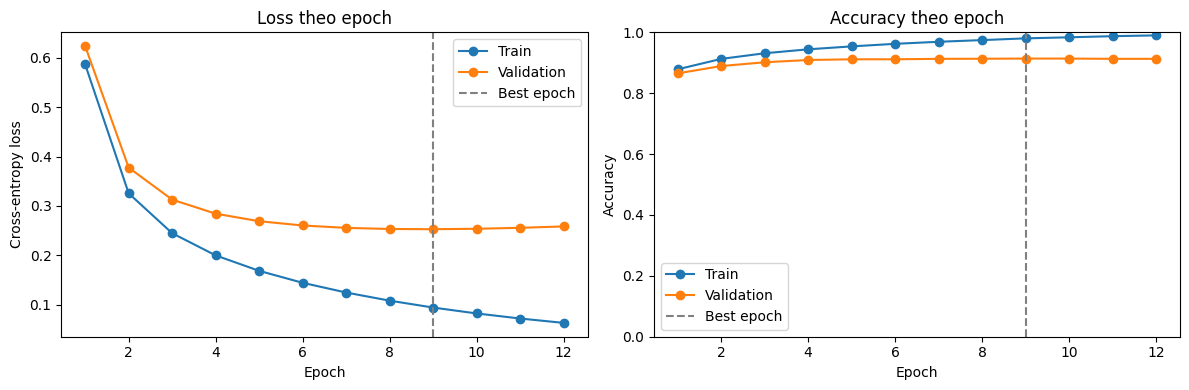

In [6]:
evaluator.plot_history(history, best_epoch)

## 4. Kết quả trên test set

Accuracy cho biết tỷ lệ dự đoán đúng toàn bộ. Precision, recall và F1-score theo từng lớp giúp phát hiện trường hợp accuracy tổng thể che khuất một lớp khó. Macro average coi mọi lớp quan trọng như nhau; weighted average có xét số mẫu của từng lớp.

In [7]:
test_predictions = model.predict(X_test)
test_accuracy, test_report = evaluator.metrics(
    test_labels, test_predictions, class_names
)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Best epoch  : {best_epoch}")
print(f"Best val loss: {best_val_loss:.4f}\n")
print(test_report)

Test accuracy: 0.9230
Best epoch  : 9
Best val loss: 0.2529

                  precision    recall  f1-score   support

Chinh tri Xa hoi     0.8449    0.9252    0.8832      7567
        Doi song     0.8321    0.6768    0.7465      2036
        Khoa hoc     0.8746    0.8220    0.8475      2096
      Kinh doanh     0.9455    0.8785    0.9108      5276
       Phap luat     0.9231    0.9219    0.9225      3788
        Suc khoe     0.9328    0.9511    0.9419      5417
        The gioi     0.9589    0.9369    0.9477      6716
        The thao     0.9855    0.9799    0.9827      6667
         Van hoa     0.9305    0.9488    0.9396      6250
         Vi tinh     0.9292    0.9555    0.9422      4560

        accuracy                         0.9230     50373
       macro avg     0.9157    0.8997    0.9064     50373
    weighted avg     0.9236    0.9230    0.9224     50373



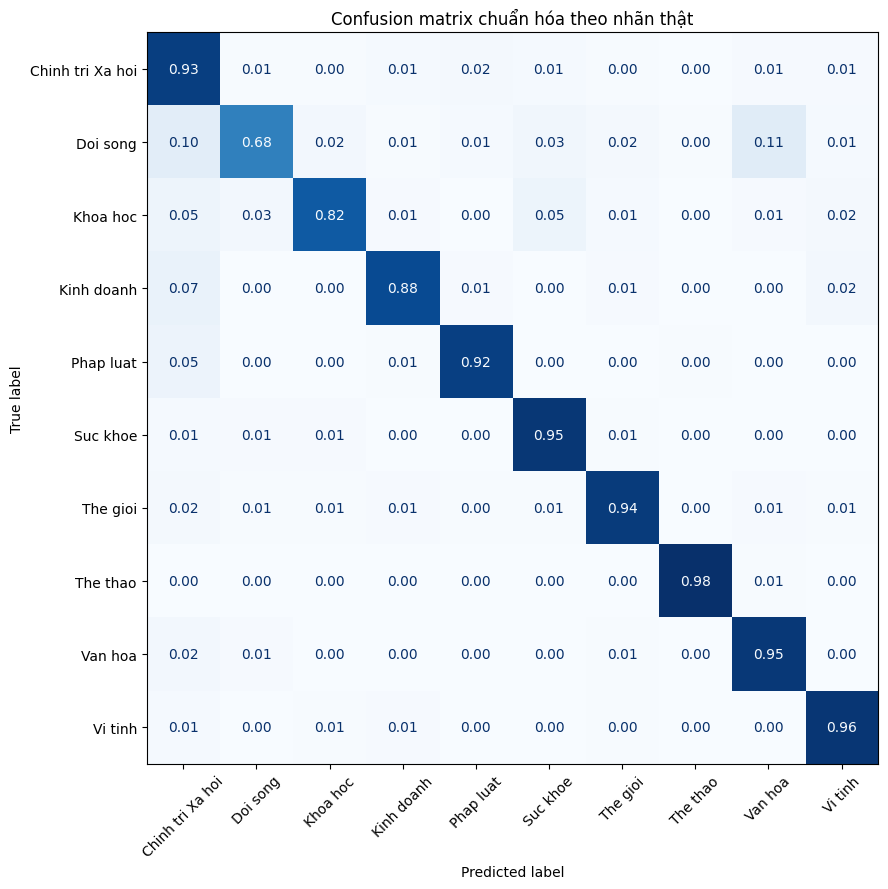

In [8]:
evaluator.plot_confusion_matrix(test_labels, test_predictions, class_names)

In [9]:
selected_indices = evaluator.correct_example_indices(
    test_labels, test_predictions, class_names
)
selected_probabilities = model.predict_proba(X_test[selected_indices])

print("MỘT DỰ ĐOÁN ĐÚNG CHO MỖI CHỦ ĐỀ\n")
for index, probabilities in zip(selected_indices, selected_probabilities):
    confidence = probabilities[class_names.index(test_predictions[index])]
    preview = test_texts[index][:CORRECT_PREVIEW_LENGTH].replace("\n", " ")
    print(f"Text: {preview}...")
    print(f"Nhãn thật: {test_labels[index]} | Dự đoán: {test_predictions[index]} | Độ tin cậy: {confidence:.2%}\n")

MỘT DỰ ĐOÁN ĐÚNG CHO MỖI CHỦ ĐỀ

Text: mạo hiểm rừng đa mi cuộc hành quân khám phá thác sương mù ẩn mình trong cánh rừng đa mi (hàm thuận bắc, bình thuận) bạt ngàn là hồ thủy điện đa mi đẹp như một nàng công chúa, ngọn thác sương mù hùng vĩ, cao ngất, uốn lượ...
Nhãn thật: Chinh tri Xa hoi | Dự đoán: Chinh tri Xa hoi | Độ tin cậy: 80.27%

Text: chè sen trứng gà tách trứng gà ra cho vào nước dấm đang sôi luộc chín, vớt ra thả vào nước chín nguội, cuối cùng vớt ra cho ráo nước, rồi cho vào chè sen. nguyên liệu 100g hạt sen tươi 6 trứng gà 100g đường phèn, vani, d...
Nhãn thật: Doi song | Dự đoán: Doi song | Độ tin cậy: 99.04%

Text: 857 loài động, thực vật ở vn bị đe dọa tuyệt chủng hồ việt an - quảng nam được bảo vệ tốt nên đã có nhiều loại chim quý hiếm đến sinh sống. ảnh: ttxvn (nlđ)- theo một điều tra mới đây của cục bảo vệ môi trường (bộ tài ng...
Nhãn thật: Khoa hoc | Dự đoán: Khoa hoc | Độ tin cậy: 80.33%

Text: giá xe ôtô sẽ tiếp tục giảm thời gian qua, hàng loạt các hãng xe mới 

## 5. Xem nhanh lỗi dự đoán

Các ví dụ sai dưới đây giúp nối metric định lượng với nội dung thực tế. Đây là bước phân tích, không được dùng để điều chỉnh mô hình sau khi đã xem test set.

In [10]:
wrong_indices = evaluator.error_indices(test_labels, test_predictions)
for index in wrong_indices[:ERROR_EXAMPLE_COUNT]:
    preview = test_texts[index][:ERROR_PREVIEW_LENGTH].replace("\n", " ")
    print(f"Thật: {test_labels[index]:<18} | Dự đoán: {test_predictions[index]}")
    print(preview + "...\n")

Thật: Chinh tri Xa hoi   | Dự đoán: Khoa hoc
ngành công nghệ hóa thực phẩm học gì? dự định thi vào ngành công nghệ hóa thực phẩm, xin hỏi ngành này đào tạo gì, ra trường làm việc ở đâu? có trường đh nào đào tạo đầu bếp chuyên...

Thật: Chinh tri Xa hoi   | Dự đoán: Van hoa
mốt chơi hàng điệu biết nói cuối năm, tha hồ mà “điệu” hàng sale hàng hoá phục vụ cho giới trẻ ngày càng phong phú. bởi lẽ tất cả những vật dụng mà các bạn trẻ tiêu dùng đều có gu ...

Thật: Chinh tri Xa hoi   | Dự đoán: The gioi
cưới vợ ở thượng hải thượng hải là thành phố lớn nhất trung quốc (tq), cũng là thành phố có mức sống cao nhất. thành phố này còn là nơi mà giới trẻ tổ chức những đám cưới tốn kém n...

Thật: Chinh tri Xa hoi   | Dự đoán: Khoa hoc
xác ướp hoàn toàn nguyên vẹn xác ướp trong ngôi mộ cổ tại vườn đào nhật tân vẫn còn nguyên vẹn (nlđ)- các nhà khoa học thuộc viện khảo cổ học vn đã tiến hành chuyển xác ướp phát hi...

Thật: Chinh tri Xa hoi   | Dự đoán: Kinh doanh
điểm nhấn quan hệ giữa doanh nghiệ